<a href="https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [10]:
import os

repo = "/content/flyrank-ml-internship-starter"

if not os.path.exists(repo):
    !git clone -q https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

print("Repository exists:", os.path.exists(repo))
print("Repository path:", repo)

Repository exists: True
Repository path: /content/flyrank-ml-internship-starter


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

For Lane 2 — Refresh / Content Opportunity Scoring, I will use Logistic Regression as the first ML model.

The task is to estimate the likelihood of content-performance decline using information available at the decision moment. Logistic Regression fits this binary prediction setup and provides an interpretable baseline model that can be compared with the Week-4 rule-based score.

I chose this method because the goal is not to maximize model complexity. The goal is to test whether a simple, interpretable ML model can provide useful decision-support ranking beyond the existing rule-based baseline.

The model uses only the selected development features. Label-derived fields such as trend_direction and trend_pct are not used as model features.

In [12]:
import pandas as pd
import numpy as np
import os

raw_path = os.path.join(
    repo,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

print("Raw dataset exists:", os.path.exists(raw_path))

df = pd.read_csv(raw_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Shape:", df.shape)

Raw dataset exists: True
Rows: 30000
Columns: 44
Shape: (30000, 44)


In [13]:
model_df = df.copy()

model_df["target"] = (
    model_df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Target distribution:")
print(model_df["target"].value_counts())

print("\nDecline rate:",
      round(model_df["target"].mean(), 4))

Target distribution:
target
1    16262
0    13738
Name: count, dtype: int64

Decline rate: 0.5421


In [14]:
feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "char_count",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

print("Number of features:", len(feature_cols))

Number of features: 19


In [15]:
feature_df = model_df[feature_cols + ["target"]].copy()

for col in feature_cols:
    feature_df[col] = pd.to_numeric(
        feature_df[col],
        errors="coerce"
    ).fillna(0)

print("Feature dataframe shape:", feature_df.shape)
print("Total missing values:",
      feature_df.isna().sum().sum())

Feature dataframe shape: (30000, 20)
Total missing values: 0


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I use a stratified 80/20 holdout split because the starter content-level dataset does not expose an observation-date field that can support a true chronological split.

The training data contains 24,000 rows and the held-out test data contains 6,000 rows. Stratification keeps the decline rate similar between the two groups.

The target is created from trend_direction, while label-derived fields such as trend_direction and trend_pct are excluded from the model features.

The evaluation is intended as a development-level comparison between the Logistic Regression model and the Week-4 rule-based baseline. It should not be interpreted as a true future-month or production validation.

In [16]:
from sklearn.model_selection import train_test_split

X = feature_df.drop(columns=["target"])
y = feature_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining decline rate:",
      round(y_train.mean(), 4))

print("Testing decline rate:",
      round(y_test.mean(), 4))

Training rows: 24000
Testing rows: 6000

Training decline rate: 0.5421
Testing decline rate: 0.542


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

I trained a Logistic Regression model using the same 30,000-page development population used for the Week-4 rule-based baseline.

The starter content-level dataset does not expose an observation date, so a true chronological train/test split cannot be reconstructed from this table alone. I therefore use a stratified 80/20 holdout for development evaluation.

The model uses 19 numeric features describing visibility, traffic, engagement, content age, freshness, and content size. The target is the decline label derived from the development dataset.

The Logistic Regression model achieved a ROC-AUC of 0.6777 and Average Precision of 0.6945 on the 6,000-page test set.

The baseline is evaluated on the same test pages using the same metrics. This makes the comparison a development-level decision-support comparison rather than a claim of future production performance.


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

ml_scores = model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully.")
print("Number of predictions:", len(ml_scores))

Logistic Regression trained successfully.
Number of predictions: 6000


In [18]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

roc_auc = roc_auc_score(
    y_test,
    ml_scores
)

pr_auc = average_precision_score(
    y_test,
    ml_scores
)

print("LOGISTIC REGRESSION")
print("-------------------")
print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(pr_auc, 4))

LOGISTIC REGRESSION
-------------------
ROC-AUC: 0.6777
Average Precision: 0.6945


In [19]:
import os
import sys
import subprocess

os.chdir(repo)

print("Running feature preparation...")
print("=" * 60)

subprocess.run(
    [sys.executable, "scripts/01_prepare_features.py"],
    check=True
)

print("\nFeature preparation completed.")

print("\nRunning baseline scoring...")
print("=" * 60)

subprocess.run(
    [sys.executable, "scripts/02_baseline_score.py"],
    check=True
)

print("\nBaseline scoring completed.")

Running feature preparation...

Feature preparation completed.

Running baseline scoring...

Baseline scoring completed.


In [20]:
baseline_path = os.path.join(
    repo,
    "data",
    "processed",
    "baseline_refresh_queue.csv"
)

print("Baseline path:")
print(baseline_path)

print("\nBaseline file exists:",
      os.path.exists(baseline_path))

if not os.path.exists(baseline_path):
    raise FileNotFoundError(
        "baseline_refresh_queue.csv was not generated."
    )

baseline_df = pd.read_csv(baseline_path)

print("\nBaseline shape:",
      baseline_df.shape)

print("\nBaseline columns:")
print(baseline_df.columns.tolist())

Baseline path:
/content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv

Baseline file exists: True

Baseline shape: (30000, 22)

Baseline columns:
['content_id', 'client_id', 'baseline_rank', 'baseline_refresh_score', 'visibility_score', 'freshness_risk_score', 'position_opportunity_score', 'depth_gap_score', 'reason_codes', 'suggested_action_baseline', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction']


In [21]:
# Create lookup using content_id
baseline_lookup = baseline_df.set_index("content_id")

# Get content IDs belonging to the ML test set
test_content_ids = df.loc[
    X_test.index,
    "content_id"
]

# Retrieve the baseline score for those exact pages
baseline_scores = (
    baseline_lookup
    .loc[
        test_content_ids,
        "baseline_refresh_score"
    ]
    .astype(float)
    .to_numpy()
)

print("Baseline scores:", len(baseline_scores))
print("Test rows:", len(y_test))

print(
    "Missing baseline scores:",
    pd.isna(baseline_scores).sum()
)

Baseline scores: 6000
Test rows: 6000
Missing baseline scores: 0


In [22]:
test_labels_from_baseline = (
    baseline_lookup
    .loc[
        test_content_ids,
        "is_declining_label"
    ]
    .astype(int)
    .to_numpy()
)

labels_match = np.array_equal(
    test_labels_from_baseline,
    y_test.to_numpy()
)

print("Baseline/test labels match:", labels_match)

if not labels_match:
    raise ValueError(
        "Baseline labels do not match the ML test labels."
    )

Baseline/test labels match: True


In [23]:
baseline_auc = roc_auc_score(
    y_test,
    baseline_scores
)

baseline_ap = average_precision_score(
    y_test,
    baseline_scores
)

print("RULE-BASED BASELINE")
print("--------------------")
print("ROC-AUC:",
      round(baseline_auc, 4))

print("Average Precision:",
      round(baseline_ap, 4))

RULE-BASED BASELINE
--------------------
ROC-AUC: 0.5787
Average Precision: 0.5699


In [24]:
comparison = pd.DataFrame({
    "Approach": [
        "Week-4 Rule-based Baseline",
        "Logistic Regression"
    ],
    "ROC-AUC": [
        baseline_auc,
        roc_auc
    ],
    "Average Precision": [
        baseline_ap,
        pr_auc
    ]
})

display(
    comparison.round(4)
)

,Approach,ROC-AUC,Average Precision
0,Week-4 Rule-based Baseline,0.5787,0.5699
1,Logistic Regression,0.6777,0.6945


In [25]:
auc_difference = roc_auc - baseline_auc
ap_difference = pr_auc - baseline_ap

print("MODEL VS BASELINE DIFFERENCE")
print("----------------------------")

print(
    "ROC-AUC difference:",
    round(auc_difference, 4)
)

print(
    "Average Precision difference:",
    round(ap_difference, 4)
)

MODEL VS BASELINE DIFFERENCE
----------------------------
ROC-AUC difference: 0.099
Average Precision difference: 0.1246


In [26]:
final_comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Average Precision"
    ],
    "Rule-based Baseline": [
        baseline_auc,
        baseline_ap
    ],
    "Logistic Regression": [
        roc_auc,
        pr_auc
    ],
    "Difference (ML - Baseline)": [
        auc_difference,
        ap_difference
    ]
})

display(
    final_comparison.round(4)
)

,Metric,Rule-based Baseline,Logistic Regression,Difference (ML - Baseline)
0,ROC-AUC,0.5787,0.6777,0.0990
1,Average Precision,0.5699,0.6945,0.1246


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## 4. Errors and interpretation

The error analysis focuses on where the Logistic Regression model makes incorrect predictions and which input features have the strongest influence on its predictions.

False positives are pages predicted as declining when the observed label is non-declining. False negatives are pages predicted as non-declining when the observed label is declining.

Predictions close to a probability of 0.5 are treated as uncertain because the model has less separation between the two classes in these cases.

Because the model uses standardized numeric features, the magnitude of its coefficients provides an interpretable indication of which features contribute most strongly to the predicted decline probability. Positive coefficients increase the predicted probability of decline, while negative coefficients decrease it.

This analysis is a development diagnostic. It helps identify model behavior and possible limitations, but it does not establish causal relationships between the features and content decline.

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Create a dataframe for error analysis

error_df = df.loc[X_test.index].copy()

error_df["actual"] = y_test.to_numpy()
error_df["ml_score"] = ml_scores

# Convert probability into a binary prediction
# 1 = predicted declining
# 0 = predicted non-declining
error_df["prediction"] = (
    error_df["ml_score"] >= 0.5
).astype(int)

# Identify prediction type
error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["actual"] == 0) &
    (error_df["prediction"] == 1),
    "error_type"
] = "False Positive"

error_df.loc[
    (error_df["actual"] == 1) &
    (error_df["prediction"] == 0),
    "error_type"
] = "False Negative"

print("Prediction summary:")
print(error_df["error_type"].value_counts())

Prediction summary:
error_type
Correct           3839
False Positive    1226
False Negative     935
Name: count, dtype: int64


A false positive means:

The model predicted that the content would decline, but the actual label was 0.

In [28]:
false_positives = error_df[
    error_df["error_type"] == "False Positive"
].copy()

print("Number of false positives:",
      len(false_positives))

display(
    false_positives[
        [
            "content_id",
            "actual",
            "ml_score",
            "prediction",
            "impressions_90d",
            "clicks_90d",
            "ctr",
            "avg_position",
            "engagement_rate",
            "content_age_days",
            "days_since_last_update",
            "word_count"
        ]
    ].head(10)
)

Number of false positives: 1226


,content_id,actual,ml_score,prediction,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate,content_age_days,days_since_last_update,word_count
2110,content_a1f8fe3ed192,0,0.763929,1,511,2,0.39,15.0,0.00,223,104,6466.0
26973,content_c4e573bc451c,0,0.743973,1,595,1,0.17,5.2,0.00,112,20,2602.0
17195,content_236f562c02a8,0,0.773077,1,3131,1,0.03,21.2,0.00,139,104,5572.0
17941,content_56d505ab01b2,0,0.748873,1,510,3,0.59,12.0,0.00,112,20,2363.0
19871,content_ef324be709a5,0,0.553354,1,70,0,0.00,12.6,0.00,90,20,3510.0
22278,content_8c061f793e00,0,0.645820,1,22187,18,0.08,5.2,2.17,236,104,NaN
23793,content_873decd76dc4,0,0.681079,1,7715,0,0.00,49.2,0.00,118,20,3747.0
21209,content_da9b0ec85c3d,0,0.758234,1,859,1,0.12,7.2,0.00,111,20,1477.0
26874,content_84e7b1e6b9be,0,0.519854,1,70,1,1.43,11.8,0.00,138,28,3278.0
792,content_c348dab76641,0,0.705632,1,155,0,0.00,7.9,0.00,203,20,3746.0


A false negative means:

The model predicted that the content would not decline, but the actual label was 1.

In [29]:
false_negatives = error_df[
    error_df["error_type"] == "False Negative"
].copy()

print("Number of false negatives:",
      len(false_negatives))

display(
    false_negatives[
        [
            "content_id",
            "actual",
            "ml_score",
            "prediction",
            "impressions_90d",
            "clicks_90d",
            "ctr",
            "avg_position",
            "engagement_rate",
            "content_age_days",
            "days_since_last_update",
            "word_count"
        ]
    ].head(10)
)

Number of false negatives: 935


,content_id,actual,ml_score,prediction,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate,content_age_days,days_since_last_update,word_count
8484,content_a128777972dd,1,0.432861,0,1666,0,0.00,7.9,0.00,557,20,NaN
27890,content_b6adeae99103,1,0.420386,0,881,1,0.11,15.8,0.00,463,22,NaN
5738,content_a0744f34c5d8,1,0.426932,0,31,0,0.00,12.0,0.00,358,104,1204.0
25967,content_dbeaa2257870,1,0.261081,0,373,0,0.00,60.4,0.00,502,20,NaN
13530,content_d63c11c0e82c,1,0.356601,0,158,0,0.00,23.4,0.00,460,22,NaN
11694,content_fefba358f0c9,1,0.161133,0,11,0,0.00,34.9,0.00,482,22,NaN
14619,content_7de54e2da10a,1,0.363929,0,76,0,0.00,6.2,0.00,460,22,NaN
989,content_4c3468a3efad,1,0.236310,0,16,0,0.00,53.6,12.50,348,20,3293.0
9770,content_da284c9673e7,1,0.446064,0,321,2,0.62,24.4,0.00,460,22,NaN
15393,content_b4b98c538d41,1,0.459661,0,1276,1,0.08,20.9,3.03,482,22,NaN


A probability close to 0.5 means the model is relatively uncertain.

In [30]:
uncertain_df = error_df.copy()

uncertain_df["distance_from_0_5"] = (
    uncertain_df["ml_score"] - 0.5
).abs()

uncertain_df = uncertain_df.sort_values(
    "distance_from_0_5"
)

print("Most uncertain predictions:")

display(
    uncertain_df[
        [
            "content_id",
            "actual",
            "ml_score",
            "prediction",
            "error_type",
            "impressions_90d",
            "ctr",
            "avg_position",
            "engagement_rate",
            "content_age_days",
            "days_since_last_update",
            "word_count"
        ]
    ].head(10)
)

Most uncertain predictions:


,content_id,actual,ml_score,prediction,error_type,impressions_90d,ctr,avg_position,engagement_rate,content_age_days,days_since_last_update,word_count
25381,content_fe7ffaf43098,1,0.499964,0,False Negative,50,0.00,6.7,0.00,221,20,3630.0
19635,content_e42d8912bdcb,1,0.500138,1,Correct,65,0.00,51.5,0.00,180,28,4948.0
26668,content_4d100cde8a08,1,0.499818,0,False Negative,16,0.00,6.7,0.00,126,28,2977.0
18848,content_61873e150f71,0,0.499812,0,Correct,56897,0.16,21.9,2.11,151,104,4742.0
6671,content_c0e7c21caccd,1,0.499788,0,False Negative,141,0.00,3.4,0.00,263,20,1365.0
20258,content_1c8859f7e657,0,0.499746,0,Correct,4,0.00,6.3,0.00,98,8,2867.0
24056,content_72accc10d7e8,1,0.499716,0,False Negative,103,0.00,68.5,0.00,123,20,2500.0
22496,content_7622f74c5a4d,0,0.499694,0,Correct,1,0.00,7.0,0.00,145,104,4209.0
5947,content_5589a28d0374,1,0.500319,1,Correct,61,0.00,3.3,0.00,117,20,2642.0
9763,content_fa014137b3ea,1,0.499674,0,False Negative,6275,0.03,52.9,0.00,445,7,2985.0


In [31]:
# Extract Logistic Regression coefficients

logistic_model = model.named_steps["logistic"]

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Features with strongest model influence:")

display(
    feature_importance[
        [
            "Feature",
            "Coefficient",
            "Absolute_Coefficient"
        ]
    ].round(4)
)

Features with strongest model influence:


,Feature,Coefficient,Absolute_Coefficient
4,users_90d,-1.2520,1.2520
3,sessions_90d,1.1133,1.1133
8,days_with_impressions,0.6193,0.6193
12,word_count,0.4617,0.4617
9,days_with_sessions,-0.4545,0.4545
10,content_age_days,-0.3285,0.3285
13,char_count,-0.3074,0.3074
7,scroll_events_90d,0.2391,0.2391
11,days_since_last_update,0.1547,0.1547
15,avg_position,-0.1309,0.1309


In [32]:
print("TOP FEATURES ASSOCIATED WITH HIGHER DECLINE PROBABILITY")
print("=" * 60)

positive_features = feature_importance[
    feature_importance["Coefficient"] > 0
].sort_values(
    "Coefficient",
    ascending=False
)

display(
    positive_features[
        ["Feature", "Coefficient"]
    ].head(10).round(4)
)


print("\nTOP FEATURES ASSOCIATED WITH LOWER DECLINE PROBABILITY")
print("=" * 60)

negative_features = feature_importance[
    feature_importance["Coefficient"] < 0
].sort_values(
    "Coefficient",
    ascending=True
)

display(
    negative_features[
        ["Feature", "Coefficient"]
    ].head(10).round(4)
)

TOP FEATURES ASSOCIATED WITH HIGHER DECLINE PROBABILITY


,Feature,Coefficient
3,sessions_90d,1.1133
8,days_with_impressions,0.6193
12,word_count,0.4617
7,scroll_events_90d,0.2391
11,days_since_last_update,0.1547
2,pageviews_90d,0.1180
17,scroll_rate,0.0721
0,impressions_90d,0.0685
18,ai_traffic_pct,0.0319



TOP FEATURES ASSOCIATED WITH LOWER DECLINE PROBABILITY


,Feature,Coefficient
4,users_90d,-1.2520
9,days_with_sessions,-0.4545
10,content_age_days,-0.3285
13,char_count,-0.3074
15,avg_position,-0.1309
1,clicks_90d,-0.1046
14,ctr,-0.0717
6,ai_sessions_90d,-0.0516
16,engagement_rate,-0.0359
5,engaged_sessions_90d,-0.0012


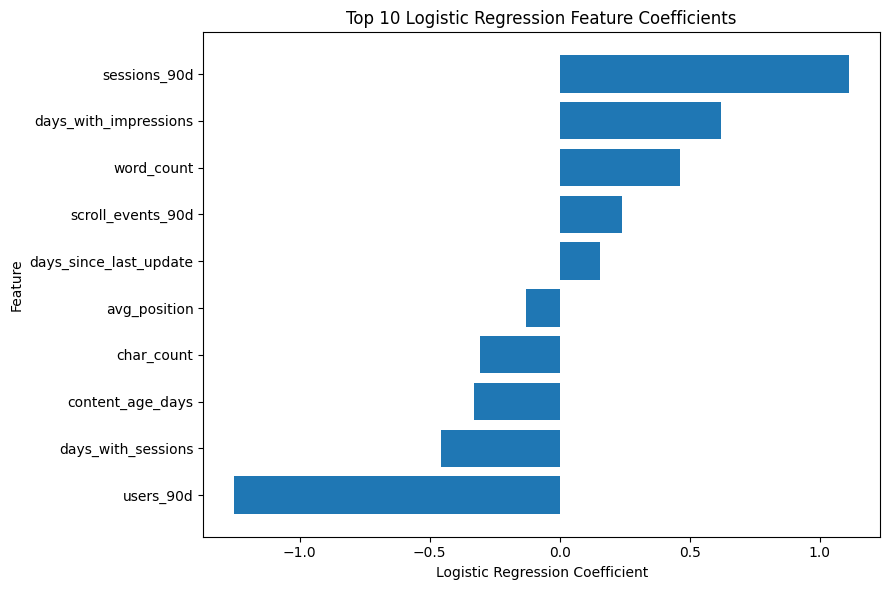

In [33]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Logistic Regression Feature Coefficients")

plt.tight_layout()
plt.show()

In [34]:
false_positive_count = (
    error_df["error_type"] == "False Positive"
).sum()

false_negative_count = (
    error_df["error_type"] == "False Negative"
).sum()

correct_count = (
    error_df["error_type"] == "Correct"
).sum()

total = len(error_df)

print("ERROR SUMMARY")
print("=" * 40)

print("Total test pages:", total)
print("Correct predictions:", correct_count)
print("False positives:", false_positive_count)
print("False negatives:", false_negative_count)

print(
    "\nError rate:",
    round(
        (false_positive_count + false_negative_count) / total,
        4
    )
)

ERROR SUMMARY
Total test pages: 6000
Correct predictions: 3839
False positives: 1226
False negatives: 935

Error rate: 0.3602


In [35]:
top_positive = positive_features.iloc[0]

top_negative = negative_features.iloc[0]

print("INTERPRETATION SUMMARY")
print("=" * 60)

print(
    f"The model produced {false_positive_count} false positives "
    f"and {false_negative_count} false negatives on the "
    f"{total}-page test set."
)

print(
    f"The strongest positive coefficient was "
    f"'{top_positive['Feature']}' "
    f"({top_positive['Coefficient']:.4f}), "
    f"which is associated with a higher predicted decline probability."
)

print(
    f"The strongest negative coefficient was "
    f"'{top_negative['Feature']}' "
    f"({top_negative['Coefficient']:.4f}), "
    f"which is associated with a lower predicted decline probability."
)

print(
    "\nThese are model associations rather than causal effects."
)

INTERPRETATION SUMMARY
The model produced 1226 false positives and 935 false negatives on the 6000-page test set.
The strongest positive coefficient was 'sessions_90d' (1.1133), which is associated with a higher predicted decline probability.
The strongest negative coefficient was 'users_90d' (-1.2520), which is associated with a lower predicted decline probability.

These are model associations rather than causal effects.


## Errors and interpretation

The error analysis shows that the Logistic Regression model makes both false-positive and false-negative predictions on the held-out test set. False positives occur when the model assigns a decline prediction to pages whose observed label is non-declining, while false negatives occur when the model does not identify pages whose observed label indicates decline.

The most uncertain predictions are pages with model scores close to 0.5. These cases indicate that the available features do not clearly separate the two classes.

The Logistic Regression coefficients provide an interpretable view of what the model leans on. Positive coefficients are associated with higher predicted decline probability, while negative coefficients are associated with lower predicted decline probability, after accounting for the other standardized features.

The strongest coefficients should therefore be interpreted as model associations rather than causal effects. The analysis also shows that some content-performance decline cases cannot be separated using the available development features alone.

Overall, the error analysis provides a more useful view of model behavior than the aggregate metrics alone. It identifies where the model is uncertain or incorrect and which measurable content characteristics contribute most strongly to its predictions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.